In [1]:
# Libarary
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets , transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [35]:
# # Data Loading into train and val

# batch_size=128
# transform=transforms.Compose([
#     transforms.ToTensor() ])

# train_dataset=datasets.MNIST(root='./data',train=True,download=True,transform=transform)
# val_dataset=datasets.MNIST(root='./data',train=False,download=True,transform=transform)

# train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)


In [36]:
# Data Loading into train and val

batch_size=128
transform=transforms.Compose([
    transforms.ToTensor() ])

train_dataset=datasets.FashionMNIST(root='./data',train=True,download=True,transform=transform)

train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.18MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.6MB/s]


In [37]:
def forward(self,x):
            z=self.encoder(x)
            x_recon=self.decoder(x)
            return x_recon

In [38]:
# Class that defines the autoencoder

class AutoEncoder(nn.Module):
    def __init__(self,hidden_dim=256,latent_dim=64):
        super().__init__()

        #Encoder
        self.encoder=nn.Sequential(
            nn.Linear(784,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,latent_dim),
            nn.ReLU()
        )

        #Decoder
        self.decoder=nn.Sequential( # Corrected: changed self.encoder to self.decoder
            nn.Linear(latent_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,784),
            nn.Sigmoid()
        )

    def forward(self,x): # Corrected: Indented 'forward' method to be inside the class
          z=self.encoder(x)
          x_recon=self.decoder(z) # Corrected: passing 'z' to decoder instead of 'x'
          return x_recon

In [39]:
#Defining the model, loss
model=AutoEncoder()
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)


In [40]:
num_epochs=5 # Renamed 'epoch' to 'num_epochs' for clarity
model.to(device) # Move the model to the GPU
model.train()

for epoch in range(num_epochs): # Iterate for num_epochs
  total_loss=0
  for x, _ in train_loader:
    x=x.view(-1,784).to(device)
    optimizer.zero_grad()

    x_recon=model(x)
    loss=criterion(x_recon,x)
    loss.backward()
    optimizer.step()

    total_loss+=loss.item()

  avg_loss=total_loss/len(train_loader)
  print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:0.6f}') # Use num_epochs here

Epoch 1/5, Loss: 0.033390
Epoch 2/5, Loss: 0.017282
Epoch 3/5, Loss: 0.014802
Epoch 4/5, Loss: 0.013362
Epoch 5/5, Loss: 0.012328


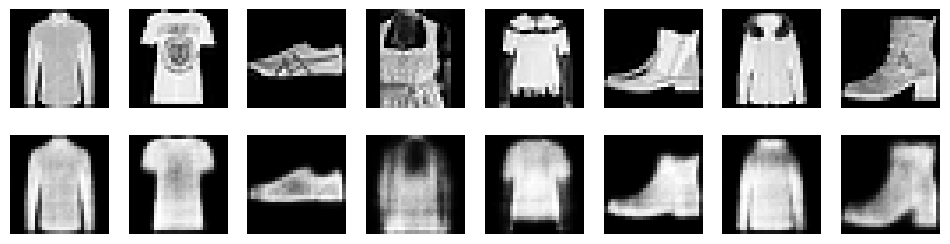

In [41]:
model.eval()

with torch.no_grad():
  x, _ =next(iter(train_loader))
  x= x.view(-1,784).to(device)

  x_recon=model(x)

  n=8
  plt.figure(figsize=(12,3))
  for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(x[i].cpu().view(28,28),cmap='gray')
    plt.axis('off')

    plt.subplot(2,n,i+1+n)
    plt.imshow(x_recon[i].cpu().view(28,28),cmap='gray')
    plt.axis('off')

  plt.show
